In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

In [2]:
sns.set_palette("Set2")

In [3]:
df = pd.read_csv('Churn_Modelling.csv')

**Таблица:** данные содержат сведения о клиентах банка, целевая переменная представляет собой бинарную переменную, отражающую тот факт, покинул ли клиент банк (закрыл свой счет) или продолжает оставаться клиентом.

# Общая информаия

In [4]:
df.shape

(10000, 14)

In [5]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2784,2785,15642202,Whitfield,821,Germany,Female,37,5,106453.53,2,0,1,127413.00,0
2824,2825,15667938,Hurst,628,France,Male,32,9,149136.31,2,1,1,16402.11,0
5604,5605,15804721,Boni,602,France,Male,49,0,191808.73,1,0,0,97640.20,0
5958,5959,15741719,DeRose,540,France,Female,40,3,165298.12,1,0,1,199862.75,0
7528,7529,15646535,Harrell,578,France,Male,46,5,113226.47,1,1,0,56770.76,0


In [6]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [7]:
df.isna().sum().sum()

0

In [8]:
df.duplicated().sum().sum()

0

**Выводы:**
- Датасет содержит 10000 строк и 14 столбцов
- Датасет не содержит пропусков
- Типы данных соответствуют ожидаемым
- Дубли отсутствуют

# Описательные статистики

In [9]:
df.describe(include=['int64', 'float64'])

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
df.describe(include=['object'])

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


1.Числовые переменные:<br>
RowNumber:<br>
Среднее значение: 5000.5, что логично, так как это просто порядковый номер строки.<br>
Минимальное значение: 1, максимальное: 10000, что соответствует количеству строк в данных.<br>

CustomerId:<br>
Среднее значение: 1.56e+07 (15,600,940), стандартное отклонение: 71,936.19.<br>
Минимальное значение: 15,565,700, максимальное: 15,815,590. Это уникальные идентификаторы клиентов.<br>

CreditScore:<br>
Средний кредитный рейтинг: 650.53, стандартное отклонение: 96.65.<br>
Минимальное значение: 350, максимальное: 850. Это соответствует стандартному диапазону кредитных рейтингов.<br>

Age:<br>
Средний возраст клиентов: 38.92 года, стандартное отклонение: 10.49.<br>
Минимальный возраст: 18 лет, максимальный: 92 года. Возраст клиентов варьируется от молодых до пожилых.<br>

Tenure:<br>
Средний срок пребывания клиента: 5.01 года, стандартное отклонение: 2.89.<br>
Минимальное значение: 0 лет, максимальное: 10 лет. Это указывает на то, что некоторые клиенты только что присоединились.<br>

Balance:<br>
Средний баланс на счетах: 76,485.89, стандартное отклонение: 62,397.41.<br>
Минимальное значение: 0, максимальное: 250,898.09. У некоторых клиентов баланс равен нулю, что может указывать на неактивные счета.

NumOfProducts:<br>
Среднее количество продуктов: 1.53, стандартное отклонение: 0.58.<br>
Минимальное значение: 1, максимальное: 4. Большинство клиентов используют 1-2 продукта.<br>

HasCrCard:<br>
Среднее значение: 0.7055, что означает, что около 70.55% клиентов имеют кредитную карту.<br>

IsActiveMember:<br>
Среднее значение: 0.5151, что означает, что около 51.51% клиентов являются активными.<br>

EstimatedSalary:<br>
Средняя зарплата: 100,000.24, стандартное отклонение: 57,510.49.<br>
Минимальное значение: 11.58, максимальное: 199,992.48. Зарплаты варьируются от очень низких до высоких.<br>

Exited:<br>
Среднее значение: 0.2037, что означает, что около 20.37% клиентов ушли (прекратили пользоваться услугами).<br>

2.Категориальные переменные:<br>
Surname:<br>
Уникальных фамилий: 2932. Наиболее часто встречающаяся фамилия: "Smith" (32 раза).<br>

Geography:<br>
Уникальных значений: 3. Наиболее часто встречающаяся страна: "France" (5014 раз).<br>

Gender:<br>
Уникальных значений: 2. Наиболее часто встречающийся пол: "Male" (5457 раз).<br>

**Выводы:**
- В колонках `CreditScore`, `Age`, `Tenure` распределене, возможно, похоже на нормальное
- Судя по разнице между `mean` и `median`, `75%` и `max` в `Balance` возможны выбросы
- `HasCrCard`, `IsActiveMember` и `Exited` являются переменными-флагами, поэтому в них значение `mean` равно доле значений True для соответствующего признака. В `IsActiveMember` оно равно примерно половине, а в `HasCrCard` и `Exited` есть дисбаланс
- В `Geography` из трех возможных значений самое частотное встречается чаще, чем в 50% строках -> дисбаланс
- `Surname` имеет слишком много уникальных значений

# Детальная информация по признакам

In [11]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

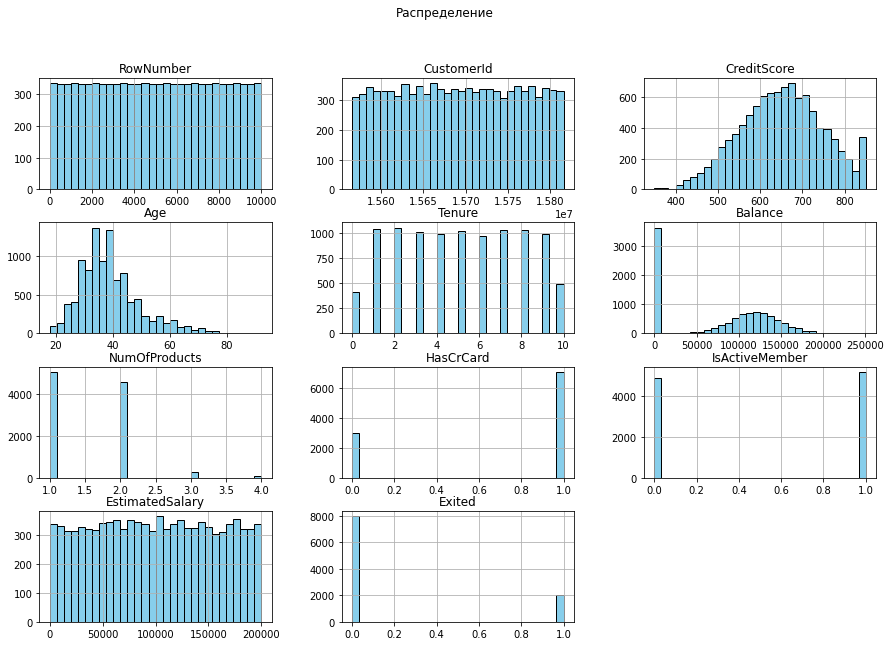

In [12]:
df.hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')

plt.suptitle('Распределение')
plt.show()

In [13]:
# Детализация распределений

for col in df.columns:
    print(f"Признак: {col}")
    print(df[col].value_counts(normalize=True).map(lambda x: "{0:.2f}%".format(100 * x)))


Признак: RowNumber
RowNumber
1        0.01%
6671     0.01%
6664     0.01%
6665     0.01%
6666     0.01%
         ...  
3334     0.01%
3335     0.01%
3336     0.01%
3337     0.01%
10000    0.01%
Name: proportion, Length: 10000, dtype: object
Признак: CustomerId
CustomerId
15634602    0.01%
15667932    0.01%
15766185    0.01%
15667632    0.01%
15599024    0.01%
            ...  
15599078    0.01%
15702300    0.01%
15660735    0.01%
15671390    0.01%
15628319    0.01%
Name: proportion, Length: 10000, dtype: object
Признак: Surname
Surname
Smith       0.32%
Scott       0.29%
Martin      0.29%
Walker      0.28%
Brown       0.26%
            ...  
Izmailov    0.01%
Bold        0.01%
Bonham      0.01%
Poninski    0.01%
Burbidge    0.01%
Name: proportion, Length: 2932, dtype: object
Признак: CreditScore
CreditScore
850    2.33%
678    0.63%
655    0.54%
705    0.53%
667    0.53%
       ...  
404    0.01%
351    0.01%
365    0.01%
417    0.01%
419    0.01%
Name: proportion, Length: 460, dtype: 

### Проверка на выбросы

In [14]:
from scipy.stats import zscore

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
z_scores = np.abs(zscore(df[numerical_cols]))
outliers = (z_scores > 3).sum(axis=0)
print("\nКол-во выбросов по каждому числовому признаку (|z|>3):\n", dict(zip(numerical_cols, outliers)))


Кол-во выбросов по каждому числовому признаку (|z|>3):
 {'RowNumber': 0, 'CustomerId': 0, 'CreditScore': 8, 'Age': 133, 'Tenure': 0, 'Balance': 0, 'NumOfProducts': 60, 'HasCrCard': 0, 'IsActiveMember': 0, 'EstimatedSalary': 0, 'Exited': 0}


**Выводы:** выбросы найденых только в тех признаках, для которых распределения отличаются от нормальных

### RowNumber, CustomerId и Surname - кандидаты для исключения из модели

In [15]:
df.RowNumber.nunique()

10000

In [16]:
df.CustomerId.nunique()

10000

In [17]:
df.Surname.nunique()

2932

#### `RowNumber`

Text(0, 0.5, 'Частота')

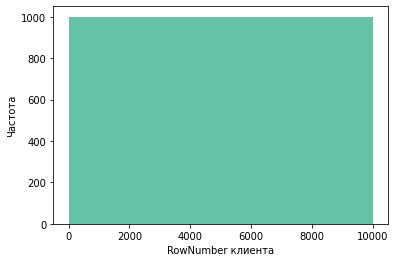

In [18]:
df.RowNumber.plot(kind='hist')

plt.xlabel('RowNumber клиента')
plt.ylabel('Частота')

* `RowNumber` - монотонно присваиваемый код клиента

#### `Customer ID`

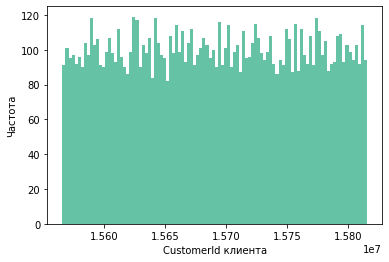

In [19]:
df.CustomerId.plot(kind='hist', bins=100)

plt.xlabel('CustomerId клиента')
plt.ylabel('Частота')

plt.show()

In [20]:
df.CustomerId.value_counts()

CustomerId
15634602    1
15667932    1
15766185    1
15667632    1
15599024    1
           ..
15599078    1
15702300    1
15660735    1
15671390    1
15628319    1
Name: count, Length: 10000, dtype: int64

* Несмотря на уникальность `ID` клиентов, это не монотонно присваиваемые номера (что можно наблюдать по гистограмме), возможно в системе хранения данных о клиентах присутствует некоторое правило присвоения уникального индекса пользователю. Однако полезной информации это не несет.

#### `Surname`

Так как данные с фамилиями не несут сильно полезной информации для дальнейшего анализа, можно из интересно изучить распределение **длины** фамилий.

In [21]:
small_df = pd.concat([df[['Surname', 'Gender', 'Exited']], df['Surname'].str.len()], axis=1)
small_df.columns = ['Surname', 'Gender', 'Exited', 'Sur_len']
small_df.head()


,Surname,Gender,Exited,Sur_len
0,Hargrave,Female,1,8
1,Hill,Female,0,4
2,Onio,Female,1,4
3,Boni,Female,0,4
4,Mitchell,Female,0,8


Количество уникальных фамилий: 2932
Наиболее часто встречающаяся фамилия: Smith
Количество её повторений: 32


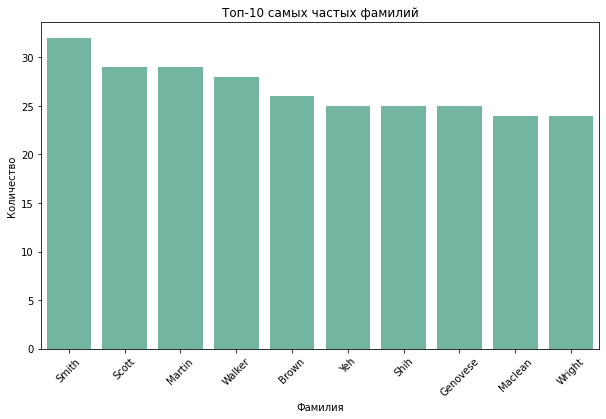

In [22]:
print("Количество уникальных фамилий:", df['Surname'].nunique())
print("Наиболее часто встречающаяся фамилия:", df['Surname'].mode()[0])
print("Количество её повторений:", df['Surname'].value_counts().max())

top_surnames = df['Surname'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_surnames.index, y=top_surnames.values)
plt.title("Топ-10 самых частых фамилий")
plt.xlabel("Фамилия")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.show()

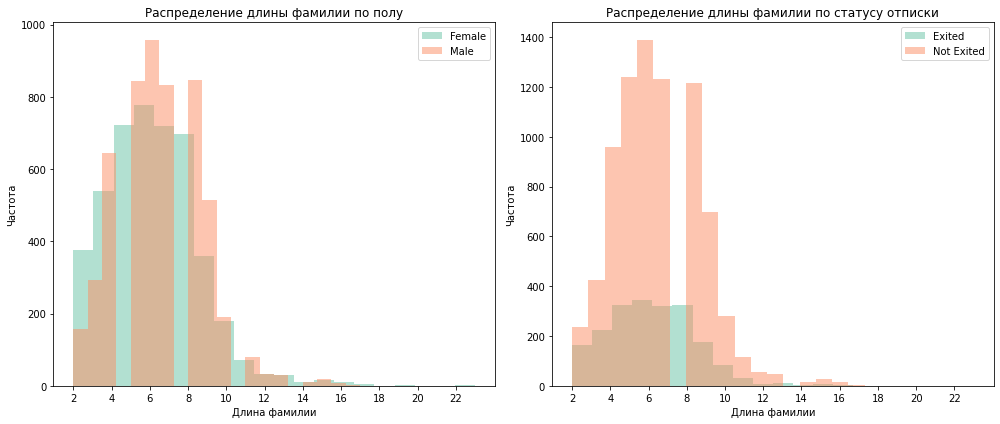

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

small_df[small_df['Gender'] == 'Female']['Sur_len'].plot(kind='hist', bins=20, alpha=0.5, label='Female', ax=axs[0], stacked=True)
small_df[small_df['Gender'] == 'Male']['Sur_len'].plot(kind='hist', bins=20, alpha=0.5, label='Male', ax=axs[0], stacked=True)
axs[0].legend()
axs[0].set_title('Распределение длины фамилии по полу')
axs[0].set_xlabel('Длина фамилии')
axs[0].set_ylabel('Частота')
axs[0].set_xticks(range(min(small_df['Sur_len']), max(small_df['Sur_len'])+1, 2))

small_df[small_df['Exited'] == 1]['Sur_len'].plot(kind='hist', bins=20, alpha=0.5, label='Exited', ax=axs[1], stacked=True)
small_df[small_df['Exited'] == 0]['Sur_len'].plot(kind='hist', bins=20, alpha=0.5, label='Not Exited', ax=axs[1], stacked=True)
axs[1].legend()
axs[1].set_title('Распределение длины фамилии по статусу отписки')
axs[1].set_xlabel('Длина фамилии')
axs[1].set_ylabel('Частота')
axs[1].set_xticks(range(min(small_df['Sur_len']), max(small_df['Sur_len'])+1, 2))

plt.tight_layout()
plt.show()

* При первоначальном осмотре уникальных фамилий сложилось впечатление, что фамилии **сгенерированы**
* Левый график показывает, что в среднем длина фамилии составляет от 5 до 8 символов
* Уже сейчас по графику можно заметить, что девушек в датасете меньше (но об этом позже)
---
* По второму графику точно нельзя сказать о том, что длина фамилии влияет на статус отписки от сервиса - распределения практически совпадают, различается лишь количество

**Вывод:** `RowNumber`, `CustomerId` - идентификаторы, не подлежат анализу. `Surname` - фамилия клиента, не имеет значения в рамках решаемой задачи

### Exited - целевая переменная - покинул ли клиент банк

In [24]:
df.Exited.nunique()

2

In [25]:
df.Exited.unique()

array([1, 0], dtype=int64)

Text(0.5, 1.0, 'Распределение статусов отписки')

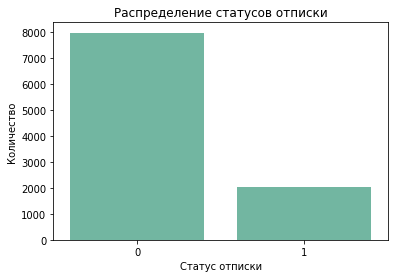

In [26]:
ax = sns.barplot(df.groupby('Exited', as_index=False).size(), x='Exited', y='size');

ax.set_xlabel('Статус отписки')
ax.set_ylabel('Количество')
ax.set_title('Распределение статусов отписки')

In [27]:
df.Exited.mean() * 100

20.369999999999997

**Вывод:** значения `Exited` соответствуют ожидаемым. По данным доля клиентов, покинувших банк - 20%

### CreditScore - кредитный рейтинг клиента

In [28]:
df.CreditScore.nunique()

460

Text(0.5, 1.0, 'Распределение кредитных рейтингов в разрезе статуса отписки')

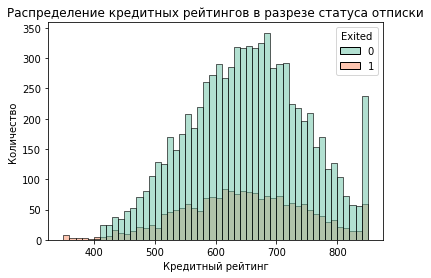

In [29]:
ax = sns.histplot(df, x='CreditScore', bins=50, hue='Exited')
ax.set_xlabel('Кредитный рейтинг')
ax.set_ylabel('Количество')
ax.set_title('Распределение кредитных рейтингов в разрезе статуса отписки')

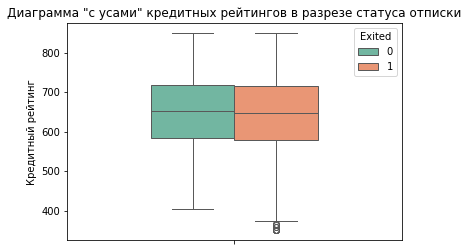

In [30]:
sns.boxplot(df, y='CreditScore', hue='Exited', width=0.5)
plt.ylabel('Кредитный рейтинг')
plt.title('Диаграмма "с усами" кредитных рейтингов в разрезе статуса отписки')

plt.show()


In [31]:
print(f"min = {df.CreditScore.min()}, max = {df.CreditScore.max()}")

min = 350, max = 850


**Вывод:** распределение `CreditScore` в целом похоже на нормальное, но максимальные значения слишком частотные. Клиенты, покинувшие банк и оставшиеся, в целом, имеют похожий кредитный рейтинг

### Geography - страна

In [32]:
df.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

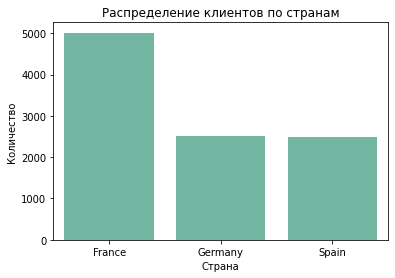

In [33]:
ax = sns.barplot(df.groupby(['Geography'], as_index=False).size(), x='Geography', y='size')
ax.set_xlabel('Страна')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по странам')

plt.show()

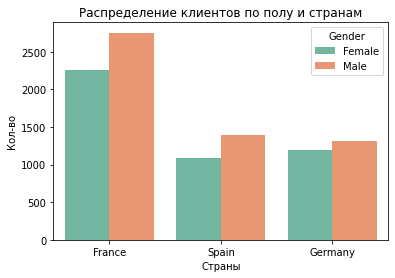

In [34]:
sns.countplot(data=df, x='Geography', hue='Gender')

plt.xlabel('Страны')
plt.ylabel('Кол-во')
plt.title('Распределение клиентов по полу и странам')

plt.show()


Text(0.5, 1.0, 'Распределение клиентов по странам в разрезе статуса отписки')

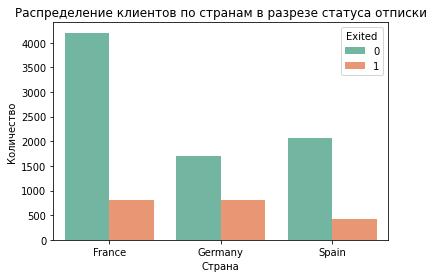

In [35]:
ax = sns.barplot(df.groupby(['Geography', 'Exited'], as_index=False).size(), x='Geography', y='size', hue='Exited')
ax.set_xlabel('Страна')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по странам в разрезе статуса отписки')

In [36]:
df.groupby(['Geography'], as_index=False).agg(count=('Exited', 'count'), exited_share=('Exited', 'mean'))

,Geography,count,exited_share
0,France,5014,0.161548
1,Germany,2509,0.324432
2,Spain,2477,0.166734


**Вывод:** 
- Половина клиентов из Франции
- Процент оттока для Франции и Испании одинаковй, а для Germany он выше

-> скорее всего, страна влияет на решение клиента покинуть банк

### Gender - пол клиента

In [37]:
df.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [38]:
df.groupby(['Gender'], as_index=False).size()

,Gender,size
0,Female,4543
1,Male,5457


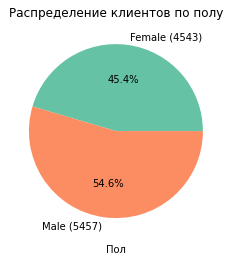

In [39]:
sizes = df.groupby(['Gender'], as_index=False).size()['size']
labels = [f"{label} ({size})" for label, size in zip(df.Gender.unique(), sizes)]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.xlabel('Пол')
plt.ylabel('')
plt.title('Распределение клиентов по полу')

plt.show()

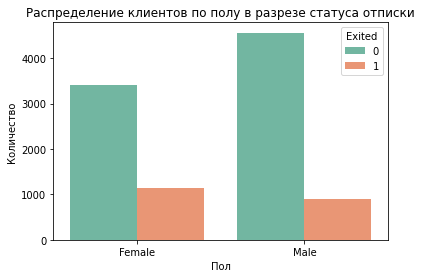

In [40]:
ax = sns.barplot(df.groupby(['Gender', 'Exited'], as_index=False).size(), x='Gender', y='size', hue='Exited')
ax.set_xlabel('Пол')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по полу в разрезе статуса отписки')

plt.show()

In [41]:
df.groupby(['Gender'], as_index=False).agg(count=('Exited', 'count'), exited_share=('Exited', 'mean'))

,Gender,count,exited_share
0,Female,4543,0.250715
1,Male,5457,0.164559


**Вывод:** 
- Вероятно, пол влияет на решение покинуть банк, т.к. среди женщин доля отказавшихся от услуг в 1.5 раза больше

### Age - возраст клиента

In [42]:
df.Age.nunique()

70

In [43]:
print(f"min = {df.Age.min()}, max = {df.Age.max()}")

min = 18, max = 92


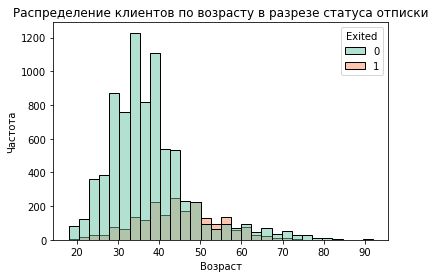

In [44]:
ax = sns.histplot(df, x='Age', bins=30, hue='Exited')
ax.set_xlabel('Возраст')
ax.set_ylabel('Частота')
ax.set_title('Распределение клиентов по возрасту в разрезе статуса отписки')

plt.show()

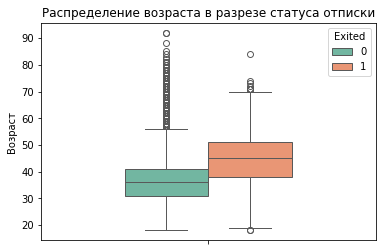

In [45]:
ax = sns.boxplot(df, y='Age', hue='Exited', width=0.5)
ax.set_ylabel('Возраст')
ax.set_title('Распределение возраста в разрезе статуса отписки')

plt.show()

**Вывод:** 
- Распределение отличается от нормального -> нужны преобразованя
- Возможно, клиенты старшего возраста больше склонны к отказу от услуг банка

### Tenure - сколько лет клиент пользуется банком

In [46]:
df.Tenure.unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0], dtype=int64)

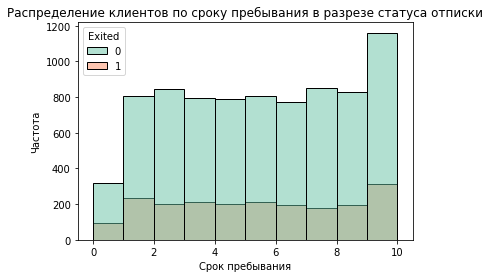

In [47]:
ax = sns.histplot(df, x='Tenure', bins=10, hue='Exited')
ax.set_xlabel('Срок пребывания')
ax.set_ylabel('Частота')
ax.set_title('Распределение клиентов по сроку пребывания в разрезе статуса отписки')

plt.show()

**Вывод:** 
- Распределение близко к равномерному -> влияния на целевую переменную нет

### Balance - баланс банковского счета клиента

In [48]:
print(f"min = {df.Balance.min()}, max = {df.Balance.max()}")

min = 0.0, max = 250898.09


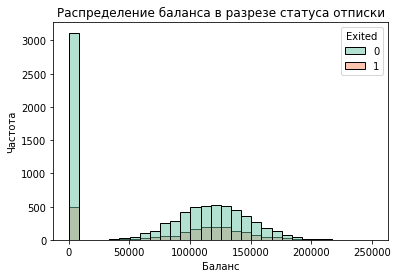

In [49]:
ax = sns.histplot(df, x='Balance', bins=30, hue='Exited')
ax.set_xlabel('Баланс')
ax.set_ylabel('Частота')
ax.set_title('Распределение баланса в разрезе статуса отписки')

plt.show()

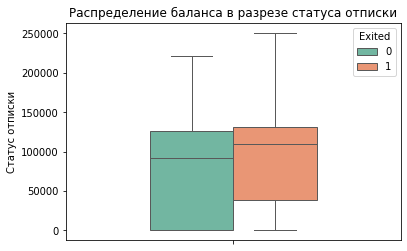

In [50]:
ax = sns.boxplot(df, y='Balance', hue='Exited', width=0.5)
ax.set_ylabel('Статус отписки')

ax.set_title('Распределение баланса в разрезе статуса отписки')

plt.show()

**Вывод:** 
- Много клиентов с нулевым балансом
- Среди клиентов с нулевым балансом доля отказов выше, чем среди клиентов с ненулевым балансом
- Распределение клиентов с ненулевым балансом близко к нормальному

### NumOfProducts - количество банковских продуктов, которыми пользуется клиент

In [54]:
df.NumOfProducts.unique()

array([1, 3, 2, 4])

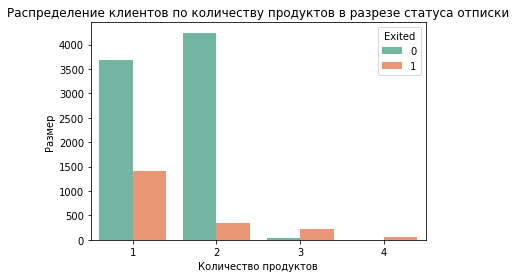

In [51]:
ax = sns.barplot(df.groupby(['NumOfProducts', 'Exited'], as_index=False).size(), x='NumOfProducts', y='size', hue='Exited')
ax.set_xlabel('Количество продуктов')
ax.set_ylabel('Размер')
ax.set_title('Распределение клиентов по количеству продуктов в разрезе статуса отписки')

plt.show()

In [52]:
df.groupby(['NumOfProducts'], as_index=False).agg(count=('Exited', 'count'), exited_share=('Exited', 'mean'))

,NumOfProducts,count,exited_share
0,1,5084,0.277144
1,2,4590,0.075817
2,3,266,0.827068
3,4,60,1.000000


**Вывод:** 
- Есть дисбаланс в классах -> можно объединить клиентов, имеющих 3 или 4 продукта в один класс
- Самый низкий процент оттока среди клиентов, имеющих 2 продутка

### HasCrCard - есть ли у клиента кредитная карта

In [53]:
df.HasCrCard.unique()

array([1, 0], dtype=int64)

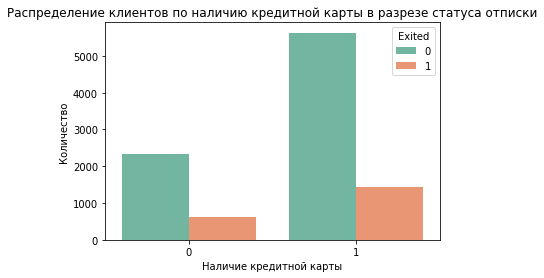

In [54]:
ax = sns.barplot(df.groupby(['HasCrCard', 'Exited'], as_index=False).size(), x='HasCrCard', y='size', hue='Exited')
ax.set_xlabel('Наличие кредитной карты')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по наличию кредитной карты в разрезе статуса отписки')

plt.show()

In [55]:
df.groupby(['HasCrCard'], as_index=False).agg(count=('HasCrCard', 'count'), exited_share=('Exited', 'mean'))

,HasCrCard,count,exited_share
0,0,2945,0.208149
1,1,7055,0.201843


**Вывод:** у большей части клиентов имеется кредитная карта, однако ее наличие не влияет на решение о том, чтобы покинуть банк

### IsActiveMember - является ли клиент активным пользователем

In [56]:
df.HasCrCard.unique()

array([1, 0], dtype=int64)

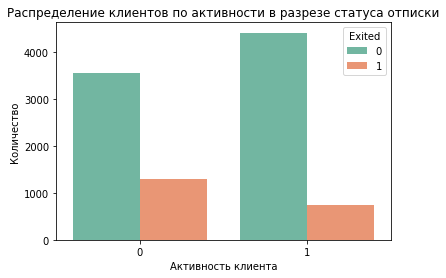

In [57]:
ax = sns.barplot(df.groupby(['IsActiveMember', 'Exited'], as_index=False).size(), x='IsActiveMember', y='size', hue='Exited')
ax.set_xlabel('Активность клиента')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по активности в разрезе статуса отписки')

plt.show()

In [58]:
df.groupby(['IsActiveMember'], as_index=False).agg(count=('IsActiveMember', 'count'), exited_share=('Exited', 'mean'))

,IsActiveMember,count,exited_share
0,0,4849,0.268509
1,1,5151,0.142691


**Вывод**:
- Доля активных и неактивных клиентов примерно одинаковая
- Активные клиенты отказываются от баконковских услуг почти в 2 раза реже

### EstimatedSalary - предполагаемая заработанная плата клиента

In [59]:
print(f"min = {df.EstimatedSalary.min()}, max = {df.EstimatedSalary.max()}")

min = 11.58, max = 199992.48


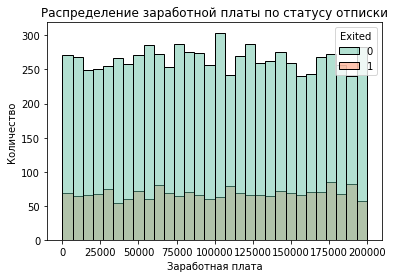

In [60]:
ax = sns.histplot(df, x='EstimatedSalary', bins=30, hue='Exited')
ax.set_xlabel('Заработная плата')
ax.set_ylabel('Количество')
ax.set_title('Распределение заработной платы по статусу отписки')

plt.show()

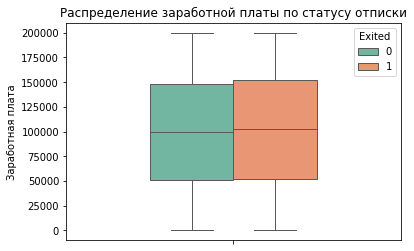

In [61]:
ax = sns.boxplot(df, y='EstimatedSalary', hue='Exited', width=0.5)
ax.set_ylabel('Заработная плата')
ax.set_title('Распределение заработной платы по статусу отписки')

plt.show()

**Вывод:**
- Распределения похожи -> вероятно, нет влияения на целевую переменную
- Распределения близки к равномерным. Для заработной платы это нетипично. Возможно, есть ошибка в данных

# Корреляции и зависимость между переменными

Рассчитаем корреляцию через `phik`. Метод позволяет вычислять взаимосвязи между различными типами признаков (категориальными, непрерывными и их комбинациями), в нем используются передовые статистические алгоритмы

In [62]:
import phik

interval columns not set, guessing: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


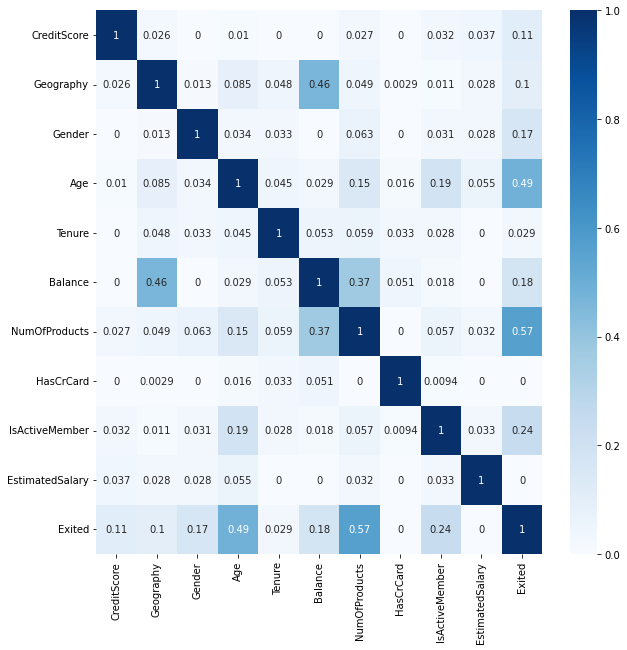

In [63]:
plt.figure(figsize=(10,10))

ph = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).phik_matrix()
sns.heatmap(ph, cmap="Blues", annot=True);

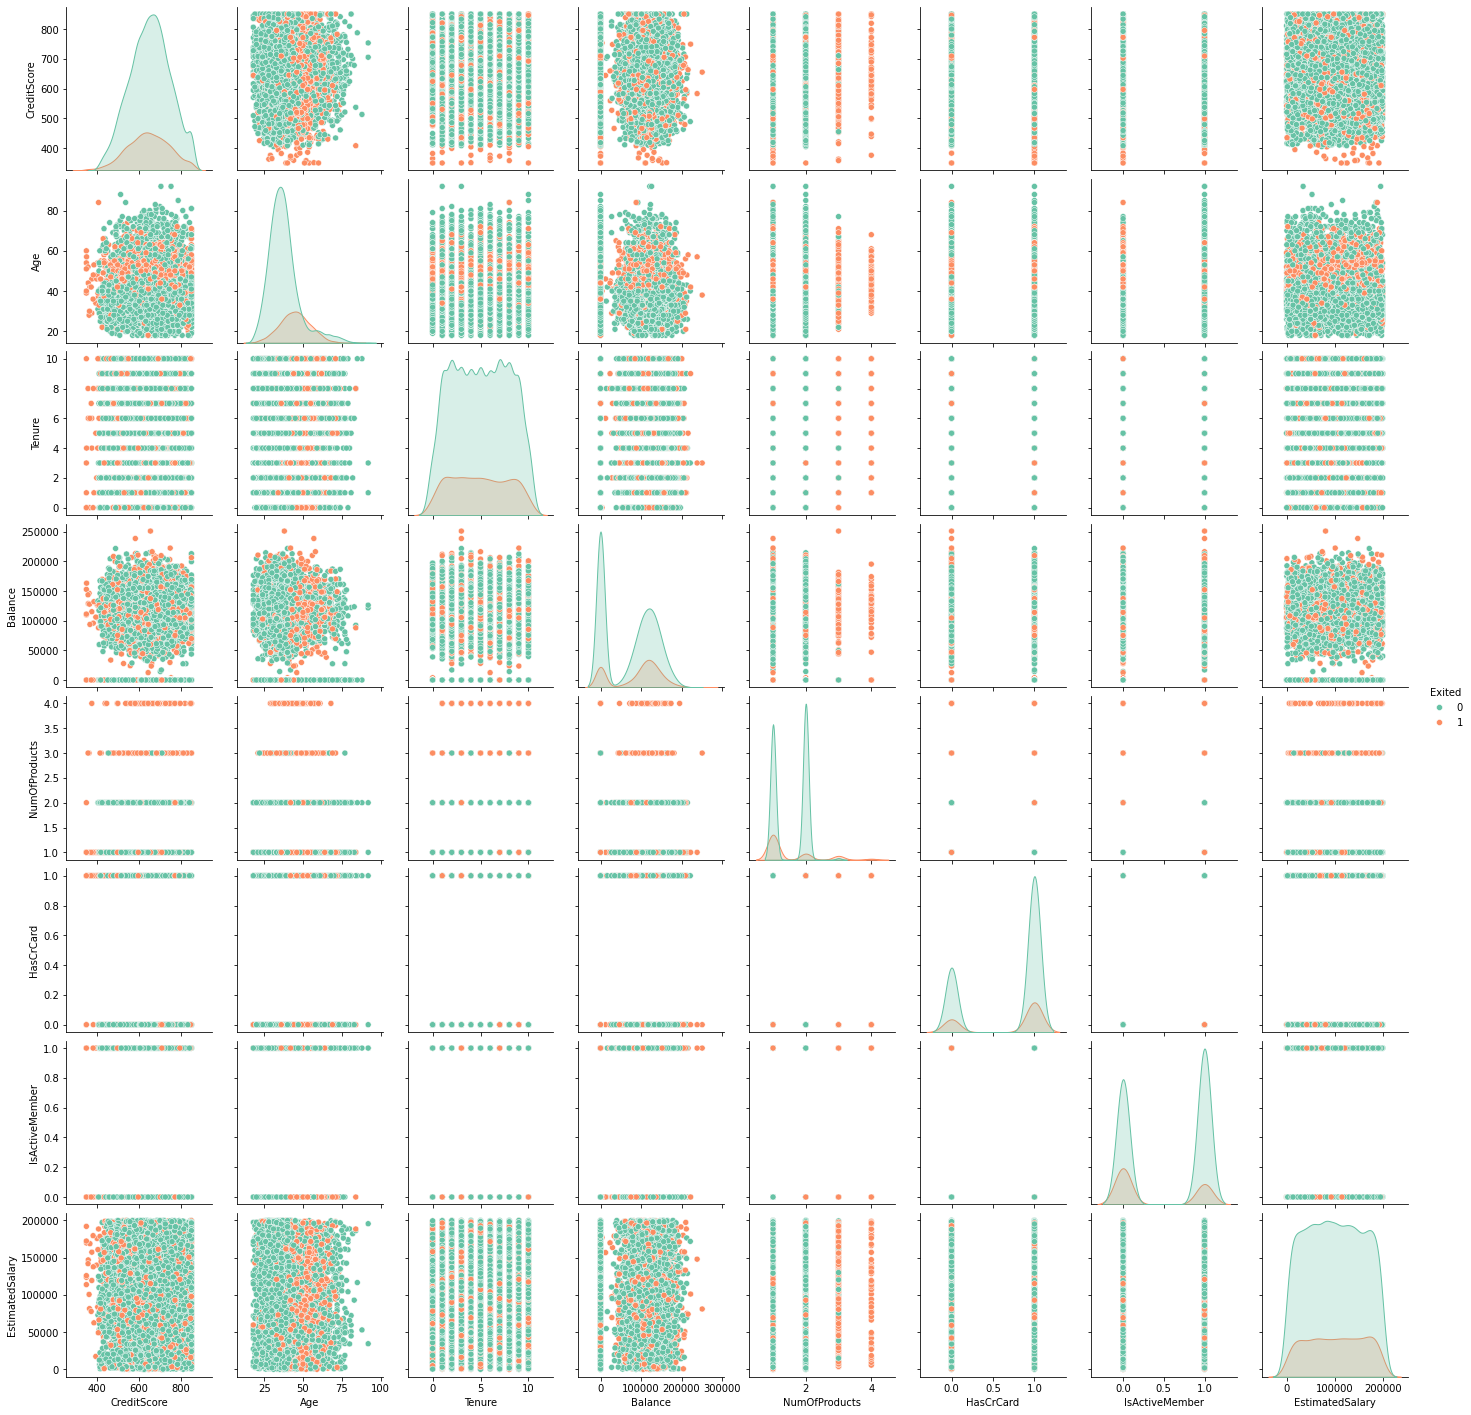

In [64]:
sns.pairplot(df[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']], hue='Exited');

Рассмотрим зависимости между нецелевыми переменными

#### Geography и Balance

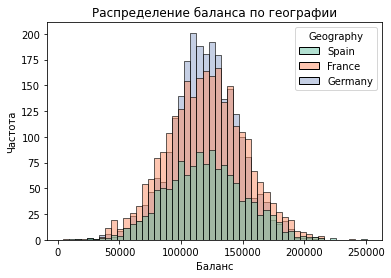

In [65]:
sns.histplot(df.query("Balance != 0"), x='Balance', bins=50, hue='Geography')
plt.xlabel('Баланс')
plt.ylabel('Частота')
plt.title('Распределение баланса по географии')

plt.show()

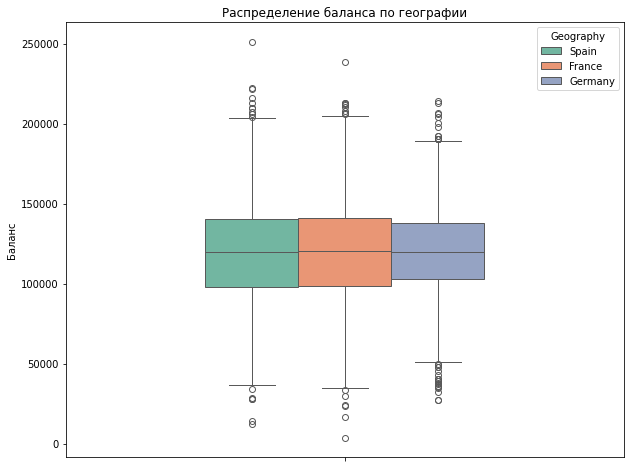

In [66]:
plt.figure(figsize=(10, 8))
sns.boxplot(df.query("Balance != 0"), y='Balance', hue='Geography', width=0.5)
plt.ylabel('Баланс')
plt.title('Распределение баланса по географии')

plt.show()

In [67]:
df['IsNullBalance'] = df.Balance.apply(lambda x: int(x == 0))

In [68]:
df.groupby(['Geography'], as_index=False).IsNullBalance.mean()

,Geography,IsNullBalance
0,France,0.482250
1,Germany,0.000000
2,Spain,0.484053


**Вывод:** в Германии нет клиентов с нулевым балансом -> смещение в данных

### Age и NumOfProducts

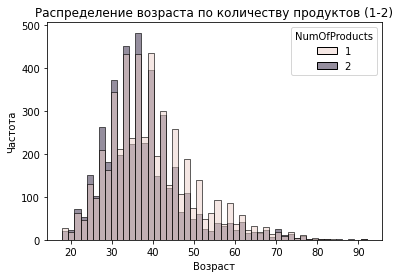

In [69]:
sns.histplot(df.query("NumOfProducts == 1 or NumOfProducts == 2"), x='Age', bins=50, hue='NumOfProducts')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.title('Распределение возраста по количеству продуктов (1-2)')

plt.show()

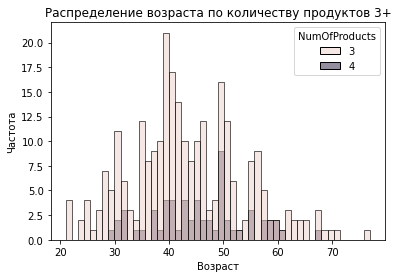

In [70]:
sns.histplot(df.query("NumOfProducts == 3 or NumOfProducts == 4"), x='Age', bins=50, hue='NumOfProducts')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.title('Распределение возраста по количеству продуктов 3+')

plt.show()

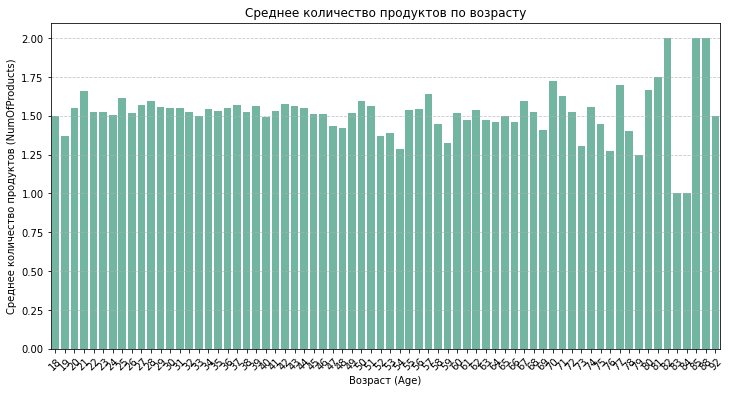

In [71]:
age_product = df.groupby('Age')['NumOfProducts'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Age', y='NumOfProducts', data=age_product)
plt.title('Среднее количество продуктов по возрасту')
plt.xlabel('Возраст (Age)')
plt.ylabel('Среднее количество продуктов (NumOfProducts)')
plt.xticks(rotation=45)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Age и IsActiveMember

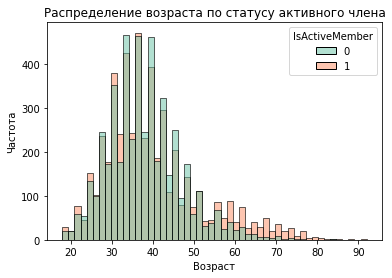

In [72]:
sns.histplot(df, x='Age', bins=50, hue='IsActiveMember')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.title('Распределение возраста по статусу активного члена')

plt.show()

### Balance и NumOfProducts

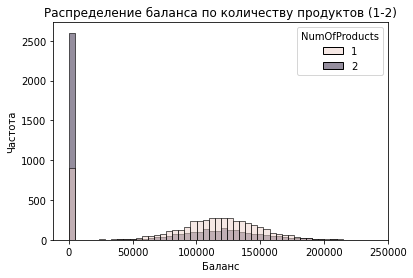

In [73]:
sns.histplot(df.query("NumOfProducts == 1 or NumOfProducts == 2"), x='Balance', bins=50, hue='NumOfProducts')
plt.xlabel('Баланс')
plt.ylabel('Частота')
plt.title('Распределение баланса по количеству продуктов (1-2)')

plt.show()

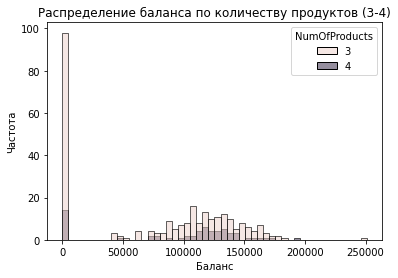

In [74]:
sns.histplot(df.query("NumOfProducts == 3 or NumOfProducts == 4"), x='Balance', bins=50, hue='NumOfProducts')
plt.xlabel('Баланс')
plt.ylabel('Частота')
plt.title('Распределение баланса по количеству продуктов (3-4)')

plt.show()

### Проверка мультиколлинеарности

In [75]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, features):
    X = df[features].dropna()
    vif = pd.DataFrame()
    vif['Feature'] = features
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

vif_df = calculate_vif(df, df.drop(columns=['RowNumber', 'CustomerId']).select_dtypes(['int', 'float']).columns)
print("\nVIF (Проверка мультиколлинеарности):\n", vif_df)


VIF (Проверка мультиколлинеарности):
            Feature        VIF
0      CreditScore  25.837248
1              Age  14.148841
2           Tenure   3.902258
3          Balance  12.640430
4    NumOfProducts   8.373156
5        HasCrCard   3.316553
6   IsActiveMember   2.150985
7  EstimatedSalary   3.910663
8           Exited   1.438627
9    IsNullBalance   8.496943


**Выводы:** `CreditScore` - высокая мультиколлинеарность, но значимой корреляции с другими признаками нет. Лучше не удалять, т.к. с бизнесовой точки зрения - это важная характеристика клиента. У `Age` уже менее критичная и `NumOfProducts` мультиколлинеарность, корреляция между этими признаками тоже не сильно большая. Примемем решение на этапе создания модели. По остальным признакам неавысокие значения VIF.

# Выводы

1. Датасет не содержит дублей и пропущенных значений. Из потенциальных ошибок - признак `EstimatedSalary` не похож на реальное распределение зарплат (т.к. его распределение равномерно)
2. Для дальнейшего анализа можно смело избавиться от первых трех колонок (`RowNumber`, `CustomerID`, `Surname`), так как они не несут особо смысла.
3. Переменные с дисбалансом в классах / смещенным распределением:
    - `Exited` (целевая): соотношение классов 20 / 80
    - `Geography`: соотношение классов примерно 50 / 25 / 25
    - `Age`: распределение смещено влево, нужно преобразование 
    - `Balance`: около трети клиентов имеют нулевой баланс, распределение клиентов с ненулым балансов близко к нормальному
    - `NumOfProducts`: мало клиентов, имещих 3 или 4 прдукта -> можно их объединить в один класс
    - `HasCrCard`: соотношение классов 30 / 70
4. Целевая переменная `Exited` больше всего зависит от:
    - `NumOfProducts`, `Age` - но есть вероятность, что это из-за смещенных и дисбалансированных распределений
    - `IsActiveMember`
    - `Gender`
    - `Geography`
5. Зависимости между нецелевыми переменными:
    - `Geography` и `Balance` - вызвано тем, что в Германии нет клиентов с нулевым балансом 
    - `Age` и `NumOfProducts` - кажется, что у клиентов старшего возраста больше продуктов, но, возможно, это искажение из-за того, что молодых клиентов больше + классы не сбалансированы. Решение об этих признаках будет принято на этапе создания модели
    - `Age` и `IsActiveMember` - аналогично
    - `Balance` и `NumOfProducts` - в целом форма распределения похожа, но надо быть осторожнее, тк классы `NumOfProducts` не сбаланисрованы

В целом, данные ОК. Рекомендуется выстраивать стратегию по их обработке в зависимости от результатов обучения моделей. Стат. значимость надо проверять осторожнее, т.к. много классов разных размеров

### Гипотеза №1

**Нулевая гипотеза ($H_0$):** Средний возраст клиентов, которые ушли, равен среднему возрасту клиентов, которые остались.

**Альтернативная гипотеза ($H_1$):** Средний возраст клиентов, которые ушли, отличается от среднего возраста тех, кто остался.

* Используем: t-test (две независимые выборки - клиенты, которые ушли (Exited = 1) и клиенты, которые остались (Exited = 0)

In [76]:
import pandas as pd
from scipy.stats import ttest_ind
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [77]:
age_exited = df[df['Exited'] == 1]['Age']
age_not_exited = df[df['Exited'] == 0]['Age']

In [78]:
t_stat, p_value = ttest_ind(age_exited, age_not_exited, equal_var=False)

print(f"T-статистика: {t_stat:.3f}")
print(f"P-значение: {p_value:.5f}")

T-статистика: 30.419
P-значение: 0.00000


In [79]:
alpha = 0.05
if p_value < alpha:
    print("Отклоняем нулевую гипотезу: средние возраста различаются.")
else:
    print("Не удалось отклонить нулевую гипотезу: статистически значимой разницы в возрасте нет.")

Отклоняем нулевую гипотезу: средние возраста различаются.


### Гипотеза №2

**Нулевая гипотеза ($H_0$):** Срок сотрудничества не вступает в зависимость с оттоком

**Альтернативная гипотеза ($H_1$):** Клиенты с небольшим сроком сотрудничества (Tenure < 2 лет) могут чаще уходить

* Предпосылки: у клиентов, кто недавно пользуется услугами еще не сформировалась лояльность к банку.

* Способ проверки гипотезы: хи-квадрат тест на независимость

* Уровень значимости: 0.05

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest

In [81]:
# Создание бинарной переменной для Tenure
df['Tenure_Group'] = np.where(df['Tenure'] < 2, 'Less than 2', '2 or more')

In [82]:
# Таблица сопряженности
contingency_table = pd.crosstab(df['Tenure_Group'], df['Exited'])
print("Таблица сопряженности:")
print(contingency_table)

Таблица сопряженности:
Exited           0     1
Tenure_Group            
2 or more     6842  1710
Less than 2   1121   327


In [83]:
# Хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Результаты хи-квадрат теста: p-value = {p_value:.4f}")

Результаты хи-квадрат теста: p-value = 0.0260


In [84]:
# Z-тест для пропорций
count = np.array([contingency_table.loc['Less than 2', 1], contingency_table.loc['2 or more', 1]])
nobs = np.array([contingency_table.loc['Less than 2'].sum(), contingency_table.loc['2 or more'].sum()])
z_stat, p_val = proportions_ztest(count, nobs)
print(f"Результаты z-теста: p-value = {p_val:.4f}")

Результаты z-теста: p-value = 0.0238


In [85]:
# Доли оттока
p_less_than_2 = count[0] / nobs[0]
p_2_or_more = count[1] / nobs[1]
print(f"Доля оттока (Tenure < 2): {p_less_than_2:.4f}")
print(f"Доля оттока (Tenure >= 2): {p_2_or_more:.4f}")

Доля оттока (Tenure < 2): 0.2258
Доля оттока (Tenure >= 2): 0.2000


### Выводы

1. Статистическая значимость различий: p-value = 0.026 (< 0.05) → Разница в оттоке статистически значима.
  * Это означает, что мы отвергаем нулевую гипотезу (о том, что срок сотрудничества не влияет на отток) и принимаем альтернативную: клиенты с небольшим сроком сотрудничества (Tenure < 2 лет) уходят достоверно чаще, чем клиенты с более длительным сроком.

2. Размер эффекта:
  * Доля оттока в группе Tenure < 2 лет: 22.58%
  * Доля оттока в группе Tenure ≥ 2 лет: 20.00%

  Абсолютная разница: 2.58 процентных пункта

3. Возможные причины:

  * Недостаточная адаптация (клиенты не успели "привыкнуть" к сервису).

  * Ошибки в onboarding-процессе (например, сложный интерфейс, отсутствие персональной поддержки).

  * Маркетинговые ожидания не совпали с реальностью (например, клиентов привлекли агрессивными акциями, но сервис их разочаровал).

In [87]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [88]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Предобработка данных

- Удаление незначимых признаков ('RowNumber', 'CustomerId', 'Surname')
- Стандартизация числовых признаков
- OHE для категориальных признаков
- Трейн / тест - 80 / 20

In [89]:
df_cleaned = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [90]:
X = df_cleaned.drop('Exited', axis=1)
y = df_cleaned['Exited']

In [91]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Логистическая регрессия

In [93]:
logistic_regression = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
logistic_regression.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'IsNullBalance']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Geography', 'Gender',
                                                   'Tenure_Group'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [96]:
y_pred = logistic_regression.predict(X_test)

In [97]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [98]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[1543   64]
 [ 314   79]]


**Вывод:** модель показала плохие результаты. Она хорошо предсказывает клиентов, которые не покинули банк (класс 0) и плохо тех, которые покинули (класс 1).

# Улучшение модели

- Используем случайный лес
- Оставим только признаки с важностью > 0.015

In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report

In [101]:
rf_selector = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selector", RandomForestClassifier(n_estimators=100, random_state=42))
])

In [102]:
rf_selector.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary',
                                                   'IsNullBalance']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['Geography', 'Gender',
                                                   'Tenure_Group'])])),
                ('feature_selector', RandomForestClassifier(random_state=42))])

In [103]:
importances = rf_selector.named_steps['feature_selector'].feature_importances_

encoded_features = (
        rf_selector
    .named_steps['preprocessor']
    .transformers_[1][1]['onehot']
    .get_feature_names_out(categorical_features)
)

feature_names = numeric_features + list(encoded_features)

feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importances

,Feature,Importance
0,Age,0.238707
1,EstimatedSalary,0.145039
2,CreditScore,0.141104
3,NumOfProducts,0.133442
4,Balance,0.128188
5,Tenure,0.076561
6,IsActiveMember,0.038508
7,Geography_Germany,0.025287
8,Gender_Male,0.019581
9,HasCrCard,0.019154


In [104]:
top_features = feature_importances.head(10)['Feature'].tolist()
top_features

['Age',
 'EstimatedSalary',
 'CreditScore',
 'NumOfProducts',
 'Balance',
 'Tenure',
 'IsActiveMember',
 'Geography_Germany',
 'Gender_Male',
 'HasCrCard']

In [105]:
selected_numeric = list(set(numeric_features).intersection(set(top_features)))
selected_categorical = [col.split("_")[0] for col in top_features if "_" in col]
selected_categorical = list(set(selected_categorical))

improved_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selected_numeric),
        ("cat", categorical_transformer, selected_categorical)
    ])

In [106]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", improved_preprocessor),
    ("classifier", RandomForestClassifier(class_weight='balanced', random_state=42))
])

In [107]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [108]:
rf_report = classification_report(y_test, y_pred_rf)
print(rf_report)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



In [109]:
rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)
print(rf_conf_matrix)

[[1552   55]
 [ 208  185]]


**Вывод:** случайный лес справляется лучше, увеличилась способность модели предсказывать ушедних клиентов (класс 1). Однако, recall по классу 1 все еще достаточно низкий - попробуем подобрать гиперпараметров

# Подбор гиперпараметров

Будем осуществлять по f1-score. Recall важен, но и в precision не хочется сильно терять

In [110]:
from sklearn.model_selection import RandomizedSearchCV

In [111]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],       
    'classifier__max_depth': [5, 10, 15, None],    
    'classifier__min_samples_split': [2, 5, 10],        
    'classifier__min_samples_leaf': [1, 2, 4, 8],        
    'classifier__max_features': ['sqrt', 'log2'],    
    'classifier__bootstrap': [True, False],            
    'classifier__class_weight': ['balanced']             
}

rf_pipeline = Pipeline([
    ('preprocessor', improved_preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=100,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [112]:
print(classification_report(y_test, best_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1607
           1       0.58      0.69      0.63       393

    accuracy                           0.84      2000
   macro avg       0.75      0.79      0.77      2000
weighted avg       0.86      0.84      0.85      2000



**Вывод:** удалось подобрать гиперпараметры так, чтобы повысить способность модели предсказывать класс 1 (ушедшие клиенты)

## Модель - XGBoost

In [115]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [116]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [117]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [118]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

In [119]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_preprocessed, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='roc_auc')

In [120]:
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}


In [121]:
y_pred = best_model.predict(X_test_preprocessed)
y_pred_proba = best_model.predict_proba(X_test_preprocessed)[:, 1]

print("--- Модель 1: XGBoost на всем датасете ---")
print("\nОтчет:")
print(classification_report(y_test, y_pred))
auc_full = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_full:.4f}")

--- Модель 1: XGBoost на всем датасете ---

Отчет:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.75      0.51      0.60       393

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

AUC-ROC: 0.8746


## Больше, выше, сильнее, лучше - подбор топ-8 признаков через `SelectKBest`

In [122]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

In [123]:
selector = SelectKBest(mutual_info_classif, k=8)
X_train_selected = selector.fit_transform(X_train_preprocessed, y_train)
X_test_selected = selector.transform(X_test_preprocessed)

onehot_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(onehot_feature_names)
selected_indices = selector.get_support(indices=True)
selected_features = [all_feature_names[i] for i in selected_indices]
print("Выбранные признаки для 2-й модели:\n", selected_features)

Выбранные признаки для 2-й модели:
 ['Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary', 'IsNullBalance', 'Geography_Germany', 'Tenure_Group_Less than 2']


In [124]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_selected, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_selected)
y_pred_proba = best_model.predict_proba(X_test_selected)[:, 1]

print("Best Parameters:", grid_search.best_params_)

print("\n--- Модель 2: XGBoost на топ-8 выбранных признаках ---")
print("\nОтчет:")
print(classification_report(y_test, y_pred))
auc_selected = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_selected:.4f}")

Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}

--- Модель 2: XGBoost на топ-8 выбранных признаках ---

Отчет:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.73      0.49      0.59       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

AUC-ROC: 0.8680


## Вывод

* Определение топ-8 признаков через `SelectKBest` не привнесло особого качество в обучение модели
* Лучшее качество AUC-ROC (0.874) было достигнуто с учетом всех признаков
* Лучшая модель в таком случае **XGBoost** c параметрами:
  * `learning_rate`: 0.2
  * `max_depth`: 3
  * `n_estimators`: 100